In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


In [57]:
df=pd.read_csv('height-weight.csv')

In [58]:
df

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160
5,78,162
6,80,163
7,90,175
8,95,182
9,78,170


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 500.0 bytes


In [60]:
df.describe()

,Weight,Height
count,23.000000,23.000000
mean,73.826087,158.391304
std,17.872407,19.511626
min,45.000000,120.000000
25%,59.000000,142.500000
50%,78.000000,162.000000
75%,86.000000,175.000000
max,105.000000,183.000000


# Data cleaning


In [61]:
df.isnull().sum()

Weight    0
Height    0
dtype: int64

# Data visualization


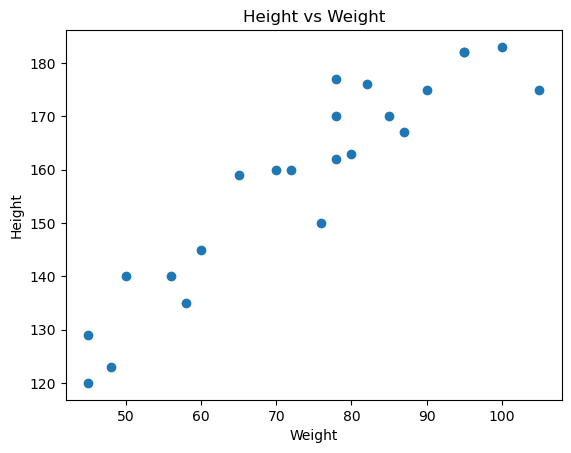

In [62]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Height vs Weight')
plt.show()

In [67]:
## divide dataset into dependendent and independent features
X=df[['Weight']]
y=df['Height']

In [68]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [69]:
X_train.shape,y_train.shape,X_test.shape,y_test.shape

((18, 1), (18,), (5, 1), (5,))

# Standardize the data


In [70]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


In [71]:
X_train

array([[ 1.73689094],
       [-0.92026952],
       [ 1.4542143 ],
       [ 0.21043706],
       [-1.48562281],
       [ 1.17153765],
       [-1.6552288 ],
       [-0.80719886],
       [-0.24184557],
       [ 0.0973664 ],
       [-1.37255215],
       [-1.03334018],
       [-0.12877492],
       [ 0.88886101],
       [ 0.43657837],
       [ 0.60618436],
       [ 0.71925502],
       [ 0.32350772]])

In [73]:
X_test

array([[ 0.21043706],
       [ 0.21043706],
       [-1.6552288 ],
       [ 1.17153765],
       [-0.52452222]])

# Model Training

In [74]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print('Mean Squared Error:',mse)
print('Root Mean Squared Error:',rmse)
print("Mean Absolute Error:",mae)
print('R2 Score:',r2)
coefficient=model.coef_
intercept=model.intercept_
print('Coefficient:',coefficient)
print('Intercept:',intercept)


Mean Squared Error: 109.77592599051654
Root Mean Squared Error: 10.477400726827076
Mean Absolute Error: 9.822657814519227
R2 Score: 0.7769869860423441
Coefficient: [17.03440872]
Intercept: 157.5


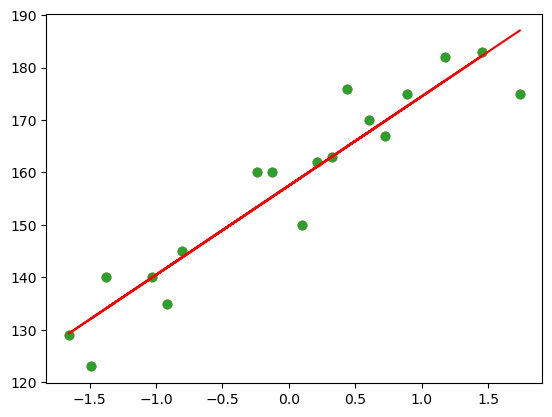

In [76]:
plt.scatter(X_train,y_train)
plt.scatter(X_train, y_train)
plt.plot(X_train, model.predict(X_train), color='red')
plt.show()
plt.show()